**Disclaimer:** The following code utilises the model as trained in: https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial8/Deep_Energy_Models.html -> See: https://github.com/phlippe/saved_models/tree/main/tutorial8

*Note: Following was run on Google Colab and the corresponding `requirements.txt` file was generated using `pip freeze` within Google Colab.*

In [ ]:
# !pip install pytorch_lightning==2.6.0

# Imports

In [ ]:
import os
from dataclasses import dataclass
import copy

import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

import pytorch_lightning as pl

from typing import Optional, Tuple, Callable, Dict, Any
import matplotlib.pyplot as plt

from contextlib import contextmanager

import urllib.request
from urllib.error import HTTPError

## Global Variables

In [ ]:
SEED = 42
pl.seed_everything(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)


CHECKPOINT_PATH = "saved_models/tutorial8"
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial8/"
pretrained_files = ["MNIST.ckpt", "tensorboards/events.out.tfevents.MNIST"]

for file_name in pretrained_files:
    file_path = os.path.join(CHECKPOINT_PATH, file_name)
    if "/" in file_name:
        os.makedirs(file_path.rsplit("/", 1)[0], exist_ok=True)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url} ...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            raise RuntimeError(f"Download failed for {file_url}: {e}")

INFO:lightning_fabric.utilities.seed:Seed set to 42


Device: cuda:0


## Pre-Trained Model

In [ ]:
### Pre-Trained Model Logic ###

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class CNNModel(nn.Module):
    def __init__(self, hidden_features=32, out_dim=1, **kwargs):
        super().__init__()
        c_hid1 = hidden_features // 2
        c_hid2 = hidden_features
        c_hid3 = hidden_features * 2

        self.cnn_layers = nn.Sequential(
            nn.Conv2d(1, c_hid1, kernel_size=5, stride=2, padding=4),
            Swish(),
            nn.Conv2d(c_hid1, c_hid2, kernel_size=3, stride=2, padding=1),
            Swish(),
            nn.Conv2d(c_hid2, c_hid3, kernel_size=3, stride=2, padding=1),
            Swish(),
            nn.Conv2d(c_hid3, c_hid3, kernel_size=3, stride=2, padding=1),
            Swish(),
            nn.Flatten(),
            nn.Linear(c_hid3 * 4, c_hid3),
            Swish(),
            nn.Linear(c_hid3, out_dim),
        )

    def forward(self, x):
        return self.cnn_layers(x).squeeze(dim=-1)


class Sampler:
    """
    Tutorial sampler used during training and for visualisation.
    """
    def __init__(self, model, img_shape, sample_size, max_len=8192):
        super().__init__()
        self.model = model
        self.img_shape = img_shape
        self.sample_size = sample_size
        self.max_len = max_len
        self.examples = [(torch.rand((1,) + img_shape) * 2 - 1) for _ in range(self.sample_size)]

    def sample_new_exmps(self, steps=60, step_size=10):
        n_new = np.random.binomial(self.sample_size, 0.05)
        rand_imgs = torch.rand((n_new,) + self.img_shape) * 2 - 1
        old_imgs = torch.cat(random.choices(self.examples, k=self.sample_size - n_new), dim=0)

        dev = next(self.model.parameters()).device
        inp_imgs = torch.cat([rand_imgs, old_imgs], dim=0).detach().to(dev)

        inp_imgs = Sampler.generate_samples(self.model, inp_imgs, steps=steps, step_size=step_size)

        self.examples = list(inp_imgs.to(torch.device("cpu")).chunk(self.sample_size, dim=0)) + self.examples
        self.examples = self.examples[: self.max_len]

        return inp_imgs

    @staticmethod
    def generate_samples(model, inp_imgs, steps=60, step_size=10, return_img_per_step=False):
        """
        Generates samples using the passe `model`, starting from `inp_imgs`.
        """
        is_training = model.training
        model.eval()
        for p in model.parameters():
            p.requires_grad = False

        inp_imgs = inp_imgs.detach()
        inp_imgs.requires_grad = True

        had_gradients_enabled = torch.is_grad_enabled()
        torch.set_grad_enabled(True)

        noise = torch.randn(inp_imgs.shape, device=inp_imgs.device)
        imgs_per_step = []

        for _ in range(int(steps)):
            noise.normal_(0, 0.005)
            inp_imgs.data.add_(noise.data)
            inp_imgs.data.clamp_(min=-1.0, max=1.0)

            out_imgs = -model(inp_imgs)
            out_imgs.sum().backward()
            inp_imgs.grad.data.clamp_(-0.03, 0.03)

            inp_imgs.data.add_(-step_size * inp_imgs.grad.data)
            inp_imgs.grad.detach_()
            inp_imgs.grad.zero_()
            inp_imgs.data.clamp_(min=-1.0, max=1.0)

            if return_img_per_step:
                imgs_per_step.append(inp_imgs.clone().detach())

        for p in model.parameters():
            p.requires_grad = True

        model.train(is_training)
        torch.set_grad_enabled(had_gradients_enabled)

        if return_img_per_step:
            return torch.stack(imgs_per_step, dim=0)

        return inp_imgs


class DeepEnergyModel(pl.LightningModule):
    def __init__(self, img_shape, batch_size, alpha=0.1, lr=1e-4, beta1=0.0, **CNN_args):
        super().__init__()
        self.save_hyperparameters()
        self.cnn = CNNModel(**CNN_args)
        self.sampler = Sampler(self.cnn, img_shape=img_shape, sample_size=batch_size)
        self.example_input_array = torch.zeros(1, *img_shape)

    def forward(self, x):
        return self.cnn(x)

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.lr, betas=(self.hparams.beta1, 0.999))
        scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.97)
        return [optimizer], [scheduler]


def load_pretrained_dem() -> DeepEnergyModel:
    """
    Loads the pretrained model from `CHECKPOINT_PATH`.
    """
    ckpt = os.path.join(CHECKPOINT_PATH, "MNIST.ckpt")

    if not os.path.isfile(ckpt):
        raise FileNotFoundError(f"Missing pretrained checkpoint: {ckpt}")

    model = DeepEnergyModel.load_from_checkpoint(ckpt)

    return model


@torch.no_grad()
def sample_with_original_tutorial_sampler(
    cnn: nn.Module,
    n_samples: int = 64,
    steps: int = 256,
    step_size: float = 10.0,
    device: torch.device = torch.device("cpu"),
) -> torch.Tensor:
    """
    Samples using the tutorial sampler kernel.
    """
    cnn.eval()
    start = torch.rand(n_samples, 1, 28, 28, device=device) * 2 - 1
    
    torch.set_grad_enabled(True)
    x = Sampler.generate_samples(cnn, start, steps=steps, step_size=step_size, return_img_per_step=False)
    torch.set_grad_enabled(False)

    return x.detach()


class MNISTEnergy(nn.Module):
    """
    Define an "Energy" wrapper consistent with training sampler (i.e. E(x) = -cnn(x)).
    """
    def __init__(self, cnn: nn.Module):
        super().__init__()
        self.cnn = cnn

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return (-self.cnn(x)).view(-1)

## Utility Functions

In [ ]:
### Reward Functions ###

def reward_bright(x: torch.Tensor) -> torch.Tensor:
    """
    Higher for brighter/higher pixel values.
    """
    x = x.clamp(-1.0, 1.0)
    return x.mean(dim=(1, 2, 3))

def reward_dark(x: torch.Tensor) -> torch.Tensor:
    """
    Higher for darker/lower pixel values.
    """
    x = x.clamp(-1.0, 1.0)
    
    return -x.mean(dim=(1, 2, 3))

def reward_bottom_concentration(x: torch.Tensor) -> torch.Tensor:
    """
    Higher when bottom half is brighter than top half.
    """
    x = x.clamp(-1.0, 1.0)
    H = x.shape[-2]
    top = x[..., : H // 2, :]
    bottom = x[..., H // 2 :, :]

    return bottom.mean(dim=(1, 2, 3)) - top.mean(dim=(1, 2, 3))


### Parameter Freezing ###

@contextmanager
def freeze_params(module: nn.Module):
    """
    Temporarily freezes parameters inside the passed `module`.
    """
    old = [p.requires_grad for p in module.parameters()]
    try:
        for p in module.parameters():
            p.requires_grad_(False)
        yield
    finally:
        for p, r in zip(module.parameters(), old):
            p.requires_grad_(r)


### ULA Dynamics ###

def ula_sample(
    *,
    energy_model: nn.Module,
    x_init: torch.Tensor,
    n_steps: int,
    step_size: float,
    noise_scale: float,
    clamp_value: Optional[float] = None,  # ImpDiff may clamp -> SOSMC-ULA must set to None
) -> torch.Tensor:
    """
    Propogates `x_init` using ULA dynamics, using the passed `energy_model`, for `n_steps`.
    """
    x = x_init.detach()

    with torch.enable_grad():
        with freeze_params(energy_model):
            for _ in range(int(n_steps)):
                x.requires_grad_(True)
                e = energy_model(x).sum()
                grad_x = torch.autograd.grad(e, x, create_graph=False)[0]

                x = x.detach() - float(step_size) * grad_x.detach()
                x = x + math.sqrt(2.0 * float(step_size)) * float(noise_scale) * torch.randn_like(x)

                if clamp_value is not None:
                    x = x.clamp(-float(clamp_value), float(clamp_value))

    return x.detach()


### Particle Initialisation ###

@torch.no_grad()
def init_persistent_particles_pi0(
    *,
    energy_ref: nn.Module,
    n_particles: int,
    device: torch.device,
    tutorial_steps: int = 60,
    tutorial_step_size: float = 10.0,
    purify_steps: int = 1000,
    gamma: float = 5e-5,
    noise_scale: float = 1.0,
    clamp_value: Optional[float] = None,
) -> torch.Tensor:
    """
    Initialises particles approximately from pi_{theta0}.
    """
    if not hasattr(energy_ref, "cnn"):
        raise ValueError("energy_ref must have attribute `.cnn` (MNISTEnergy(cnn)).")

    cnn0 = energy_ref.cnn.to(device).eval()

    # Warm-start (using tutorial kernel)
    x0 = torch.rand(n_particles, 1, 28, 28, device=device) * 2 - 1
    x = Sampler.generate_samples(
        cnn0,
        x0,
        steps=int(tutorial_steps),
        step_size=float(tutorial_step_size),
        return_img_per_step=False,
    ).detach()

    # Purify (using respective training kernel under E0)
    if int(purify_steps) > 0:
        x = ula_sample(
            energy_model=energy_ref,
            x_init=x,
            n_steps=int(purify_steps),
            step_size=float(gamma),
            noise_scale=float(noise_scale),
            clamp_value=clamp_value,
        ).detach()

    return x


### Statistics ###

def pearson_corr_1d(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """
    Computes the Pearson correlation coefficient between two tensors.
    """
    a = a.flatten()
    b = b.flatten()
    a = a - a.mean()
    b = b - b.mean()
    denom = (a.std(unbiased=False) * b.std(unbiased=False)).clamp_min(eps)

    return (a * b).mean() / denom

## Utility Functions - Plotting

In [ ]:
def show_grid(x: torch.Tensor, title: str = "", nrow: int = 8):
    """
    Displays a batch of images, `x`, as a normalised grid.
    """
    x = x.detach().cpu()
    grid = torchvision.utils.make_grid(
        x, nrow=nrow, normalize=True, value_range=(-1, 1), pad_value=0.5, padding=2
    )
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(title)
    plt.show()


def _set_all_seeds(seed: int):
    """
    Sets a variety of seeds for reproducibility.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

@torch.no_grad()
def make_training_init_particles(
    *,
    energy_ref,
    n_particles: int,
    device,
    init_seed: int = 123,
    tutorial_steps: int = 256,
    tutorial_step_size: float = 10.0,
    purify_steps: int = 1000,
    gamma: float = 5e-5,
    noise_scale: float = 1.0,
    clamp_value=None,
):
    """
    Produces a collection of (reproducible) initial particles.
    """
    # Reproducible initialisation
    _set_all_seeds(init_seed)

    return init_persistent_particles_pi0(
        energy_ref=energy_ref,
        n_particles=n_particles,
        device=device,
        tutorial_steps=tutorial_steps,
        tutorial_step_size=tutorial_step_size,
        purify_steps=purify_steps,
        gamma=gamma,
        noise_scale=noise_scale,
        clamp_value=clamp_value,
    ).detach()


def set_icml_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
        "mathtext.fontset": "stix",

        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,

        "figure.dpi": 150,
        "savefig.dpi": 400,
    })


def set_icml_style_basic():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 9,
        "figure.dpi": 150,
        "savefig.dpi": 400,
    })

@torch.no_grad()
def visualise_stacked_trajectories(
    models: dict,
    *,
    x_init: torch.Tensor,
    device=None,
    steps: int = 256,
    vis_steps: int = 8,
    step_size: float = 10.0,
    sampler_noise_seed: int = 999,
    figsize=(6.8, 2.1),
    padding: int = 1,
    pad_value: float = 1.0,
    label_mode: str = "step_index",
    xlabel: str = None,
    row_label_pad: int = 18,
    savepath: str = None,
):
    """
    Visualises the sampler trajectories, for multiple `models`, 
    using identical initialisation and shared noise.
    """
    set_icml_style()

    any_model = next(iter(models.values()))
    device = device or next(any_model.parameters()).device

    checkpoints_iter = np.linspace(steps // vis_steps, steps, vis_steps, dtype=int).tolist()
    step_indices = [0] + [s - 1 for s in checkpoints_iter]

    if label_mode == "iteration":
        step_labels = [1] + checkpoints_iter
        xlab = xlabel or "Generation iteration"
    else:
        step_labels = step_indices
        xlab = xlabel or "Sampler step index"

    x0 = x_init.detach().to(device)

    rows = []
    for name, model in models.items():
        cnn = model.cnn
        cnn.eval()

        _set_all_seeds(int(sampler_noise_seed))

        torch.set_grad_enabled(True)
        imgs_per_step = Sampler.generate_samples(
            cnn,
            x0.clone(),
            steps=int(steps),
            step_size=float(step_size),
            return_img_per_step=True,
        )
        torch.set_grad_enabled(False)

        sel = imgs_per_step[step_indices]
        sel = sel.permute(1, 0, 2, 3, 4).contiguous()
        sel = sel.view(-1, 1, 28, 28)
        rows.append((name, sel.cpu()))

    K = len(step_labels)
    big = torch.cat([t for _, t in rows], dim=0)

    grid = torchvision.utils.make_grid(
        big,
        nrow=K,
        normalize=True,
        value_range=(-1, 1),
        padding=padding,
        pad_value=pad_value,
    )

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.imshow(
        grid.permute(1, 2, 0).numpy(),
        cmap="gray",
        interpolation="nearest",
        aspect="equal",
    )

    tile_w = 28
    pad = padding
    x_centers = [pad + j * (tile_w + pad) + tile_w / 2 for j in range(K)]
    ax.set_xticks(x_centers)
    ax.set_xticklabels([str(s) for s in step_labels])

    B = x0.shape[0]
    tile_h = 28
    row_h = tile_h + pad
    y_centers, y_labels = [], []
    r = 0
    for name, _ in rows:
        y_centers.append(pad + tile_h / 2 + (r + (B - 1) / 2) * row_h)
        y_labels.append(name)
        r += B

    ax.set_yticks([])

    ax.tick_params(axis="both", which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight", pad_inches=0.01, facecolor="white")
    plt.show()



@torch.no_grad()
def final_samples_by_model(
    models: dict,
    *,
    x_init: torch.Tensor,
    reward_fn,
    steps: int = 256,
    step_size: float = 10.0,
    sampler_noise_seed: int = 999,
    padding: int = 1,
    pad_value: float = 1.0,
    row_gap_px: int = 18,
    figsize=(6.8, 2.8),
    row_label_pad: int = 2,
    reward_fmt: str = "{mean:.3f} ± {std:.3f}",
    savepath: str = None,
):
    """
    Displays final (fresh) samples obtained, for the corresponding passed `models`,
    which should differ by beta_{KL} used in training, where again identical initialisation 
    and shared noise is utilised.
    """
    set_icml_style_basic()

    any_model = next(iter(models.values()))
    device = next(any_model.parameters()).device
    x0 = x_init.detach().to(device)

    finals = {}
    row_labels = []

    for name, dem in models.items():
        cnn = dem.cnn.to(device).eval()

        # Same random noise!
        _set_all_seeds(int(sampler_noise_seed))

        torch.set_grad_enabled(True)
        xT = Sampler.generate_samples(
            cnn,
            x0.clone(),
            steps=int(steps),
            step_size=float(step_size),
            return_img_per_step=False,
        )
        torch.set_grad_enabled(False)

        xT_cpu = xT.detach().cpu()
        finals[name] = xT_cpu

        r = reward_fn(xT_cpu).view(-1)
        r_mean = float(r.mean().item())
        r_std = float(r.std(unbiased=False).item())

        row_labels.append(f"{name}")

    B = x_init.shape[0]
    row_grids = []
    names = list(models.keys())
    for name in names:
        g = torchvision.utils.make_grid(
            finals[name],
            nrow=B,
            normalize=True,
            value_range=(-1, 1),
            padding=padding,
            pad_value=pad_value,
        )
        row_grids.append(g)

    W = row_grids[0].shape[-1]
    spacer = torch.full((3, row_gap_px, W), float(pad_value))

    stacked = []
    for i, g in enumerate(row_grids):
        stacked.append(g)
        if i < len(row_grids) - 1:
            stacked.append(spacer)
    big = torch.cat(stacked, dim=1)

    # Plot Logic
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.imshow(big.permute(1, 2, 0).numpy(), cmap="gray", interpolation="nearest")

    tile = 28
    pad = padding
    row_grid_h = pad + tile + pad
    y_centers = []
    y = pad + tile / 2
    for _ in names:
        y_centers.append(y)
        y += row_grid_h + row_gap_px

    ax.set_yticks(y_centers)
    ax.set_yticklabels(row_labels)
    ax.tick_params(axis="y", pad=row_label_pad)

    ax.set_xticks([])
    ax.tick_params(axis="both", which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.subplots_adjust(left=0.16, right=0.995, top=0.995, bottom=0.02)

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight", pad_inches=0.01, facecolor="white")

    plt.show()

    return finals

## Algorithms - ImpDiff

In [7]:
class ImpDiffTuner:
    """
    ImpDiff implementation.
    """
    def __init__(
        self,
        *,
        energy_model: nn.Module,
        reward_fn,
        device: torch.device,
        n_particles: int = 256,
        lr: float = 1e-6,
        beta_kl: float = 10.0,
        gamma: float = 5e-4,
        noise_scale: float = 1.0,
        clamp_value: Optional[float] = 1.0,
        steps_per_outer: int = 1,
        grad_clip_norm: float = 1000.0,
        energy_reference: Optional[nn.Module] = None,
        tutorial_steps: int = 256,
        purify_steps: int = 2000,
        eval_sampler_fn: Optional[Callable] = None,
        eval_fresh_frequency: int = 50,
        eval_fresh_n_samples: int = 64,
        eval_fresh_n_steps: int = 128,
        eval_fresh_step_size: float = 10.0,
    ):
        self.energy = energy_model.to(device)
        self.device = device
        self.reward_fn = reward_fn

        self.opt = optim.Adam(self.energy.parameters(), lr=float(lr))
        self.beta_kl = float(beta_kl)

        self.gamma = float(gamma)
        self.noise_scale = float(noise_scale)
        self.clamp_value = clamp_value
        self.steps_per_outer = int(steps_per_outer)
        self.grad_clip_norm = float(grad_clip_norm)

        # E0 (frozen reference)
        if energy_reference is None:
            self.energy_ref = copy.deepcopy(self.energy).to(device)
        else:
            self.energy_ref = energy_reference.to(device)
        self.energy_ref.eval()
        for p in self.energy_ref.parameters():
            p.requires_grad_(False)

        # Initialise particles near pi_{theta0}
        self.particles = init_persistent_particles_pi0(
            energy_ref=self.energy_ref,
            n_particles=n_particles,
            device=device,
            tutorial_steps=tutorial_steps,
            tutorial_step_size=10.0,
            purify_steps=purify_steps,
            gamma=self.gamma,
            noise_scale=self.noise_scale,
            clamp_value=self.clamp_value,
        ).detach()

        self.eval_sampler_fn = eval_sampler_fn
        self.eval_fresh_frequency = eval_fresh_frequency
        self.eval_fresh_n_samples = eval_fresh_n_samples
        self.eval_fresh_n_steps = eval_fresh_n_steps
        self.eval_fresh_step_size = eval_fresh_step_size

        self.history = {
            "step": [],
            "mean_reward": [],
            "loss_total": [],
            "loss_reward": [],
            "loss_kl": [],
            "corr_E_r": [],
            "E_mean": [],
            "E0_mean": [],
        }

        self.history.update({
            "eval_fresh_step": [],
            "fresh_reward_mean": [],
            "fresh_reward_std": [],
        })

    @torch.no_grad()
    def _eval_fresh_reward(self) -> Dict[str, float]:
        if self.eval_sampler_fn is None:
            return {"mean": float("nan"), "std": float("nan")}

        cnn = getattr(self.energy, "cnn", None)
        if cnn is None:
            raise ValueError("energy model has no attribute `.cnn` needed for eval sampler.")

        was_training = cnn.training
        cnn.eval()

        x = self.eval_sampler_fn(
            cnn,
            n_samples=self.eval_fresh_n_samples,
            steps=self.eval_fresh_n_steps,
            step_size=self.eval_fresh_step_size,
            device=self.device,
        )

        if was_training:
            cnn.train()

        r = self.reward_fn(x).detach().view(-1)
        return {
            "mean": float(r.mean().item()),
            "std": float(r.std(unbiased=False).item()),
        }

    def step(self, k: int):
        X_k = self.particles.detach()

        # Propogate particles with (potentially clamped) ULA under current theta
        self.particles = ula_sample(
            energy_model=self.energy,
            x_init=self.particles,
            n_steps=self.steps_per_outer,
            step_size=self.gamma,
            noise_scale=self.noise_scale,
            clamp_value=self.clamp_value,
        )

        # Energies
        E = self.energy(X_k).view(-1)
        with torch.no_grad():
            E0 = self.energy_ref(X_k).view(-1)

        # Reward
        r = self.reward_fn(X_k).detach().view(-1)
        r_bar = r.mean()

        # Reward surrogate
        loss_reward = ((r - r_bar) * E).mean()

        # Reverse KL surrogate
        with torch.no_grad():
            delta = (E.detach() - E0)
            delta_center = delta - delta.mean()
        loss_kl = self.beta_kl * (delta_center * E).mean()

        loss_total = loss_reward + loss_kl

        self.opt.zero_grad(set_to_none=True)
        loss_total.backward()
        nn.utils.clip_grad_norm_(self.energy.parameters(), self.grad_clip_norm)
        self.opt.step()

        with torch.no_grad():
            self.history["step"].append(int(k))
            self.history["mean_reward"].append(float(r_bar.item()))
            self.history["loss_total"].append(float(loss_total.item()))
            self.history["loss_reward"].append(float(loss_reward.item()))
            self.history["loss_kl"].append(float(loss_kl.item()))
            self.history["corr_E_r"].append(float(pearson_corr_1d(E.detach(), r.detach()).item()))
            self.history["E_mean"].append(float(E.mean().item()))
            self.history["E0_mean"].append(float(E0.mean().item()))


    def run(self, n_outer_steps: int, log_every: int = 50):
        for k in range(int(n_outer_steps)):
            self.step(k)
            if (k % int(log_every)) == 0:
                print(
                    f"[ImpDiff] step {k:5d}/{n_outer_steps} | "
                    f"loss={self.history['loss_total'][-1]: .4f} | "
                    f"rew={self.history['mean_reward'][-1]: .4f} | "
                    f"E={self.history['E_mean'][-1]: .3f} | E0={self.history['E0_mean'][-1]: .3f} | "
                )

            if self.eval_fresh_frequency > 0 and (k % self.eval_fresh_frequency) == 0:
                stats = self._eval_fresh_reward()
                self.history["eval_fresh_step"].append(int(k))
                self.history["fresh_reward_mean"].append(stats["mean"])
                self.history["fresh_reward_std"].append(stats["std"])
                print(
                    f"  Fresh-sample reward @ step {k}: "
                    f"mean={stats['mean']:.4f} std={stats['std']:.4f}"
                )

        return self.history

## Algorithms - SOSMC-ULA

In [ ]:
def normalized_weights_from_logA(logA: torch.Tensor) -> torch.Tensor:
    return torch.softmax(logA - logA.max(), dim=0)

def effective_sample_size(w: torch.Tensor) -> float:
    return float(1.0 / (w.pow(2).sum() + 1e-12))

def systematic_resample(weights: torch.Tensor) -> torch.Tensor:
    N = weights.shape[0]
    device = weights.device
    positions = (torch.arange(N, device=device, dtype=weights.dtype) + torch.rand(1, device=device)) / N
    cdf = torch.cumsum(weights, dim=0)
    idx = torch.searchsorted(cdf, positions).clamp(max=N - 1)

    return idx

def energy_and_grad_x(energy_model: nn.Module, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    with torch.enable_grad():
        x_req = x.detach().requires_grad_(True)
        with freeze_params(energy_model):
            U = energy_model(x_req).view(-1)
            gradU = torch.autograd.grad(U.sum(), x_req, create_graph=False)[0]

    return U.detach(), gradU.detach()

def alpha_ula_gaussian_kernel(
    U_x: torch.Tensor,
    gradU_x: torch.Tensor,
    x: torch.Tensor,
    x_next: torch.Tensor,
    step_size: float,
    noise_scale: float,
) -> torch.Tensor:
    """
    Computes alpha term for SOSMC-ULA.
    """
    dx = (x_next - x).reshape(x.shape[0], -1)
    g = gradU_x.reshape(x.shape[0], -1)
    s2 = float(noise_scale) ** 2
    eta = 1.0 / s2

    term1 = U_x.view(-1)
    term2 = (eta / 2.0) * (dx * g).sum(dim=1)
    term3 = (eta * float(step_size) / 4.0) * (g * g).sum(dim=1)

    return (term1 + term2 + term3).detach()


class SOSMCULATuner:
    """
    SOSMC-ULA implementation.
    """
    def __init__(
        self,
        *,
        energy_model: nn.Module,
        reward_fn,
        device: torch.device,
        n_particles: int = 256,
        lr: float = 1e-6,
        beta_kl: float = 10.0,
        gamma: float = 5e-4,
        noise_scale: float = 1.0,
        grad_clip_norm: float = 1000.0,
        energy_reference: Optional[nn.Module] = None,
        ess_resample_ratio: Optional[float] = 0.5,
        ess_adapt_ratio: Optional[float] = 0.7,
        gamma_min: Optional[float] = 1e-5,
        gamma_max: Optional[float] = 5e-3,
        adapt_factor: Optional[float] = 1.0,
        tutorial_steps: int = 256,
        purify_steps: int = 2000,
        eval_sampler_fn: Optional[Callable] = None,
        eval_fresh_frequency: int = 50,
        eval_fresh_n_samples: int = 64,
        eval_fresh_n_steps: int = 128,
        eval_fresh_step_size: float = 10.0,
    ):
        self.energy = energy_model.to(device)
        self.device = device
        self.reward_fn = reward_fn
        self.beta_kl = float(beta_kl)
        self.opt = optim.Adam(self.energy.parameters(), lr=float(lr))
        self.grad_clip_norm = float(grad_clip_norm)

        self.gamma = float(gamma)
        self.noise_scale = float(noise_scale)

        # E0 (frozen reference)
        if energy_reference is None:
            self.energy_ref = copy.deepcopy(self.energy).to(device)
        else:
            self.energy_ref = energy_reference.to(device)
        self.energy_ref.eval()
        for p in self.energy_ref.parameters():
            p.requires_grad_(False)

        # Initialise particles near pi_{theta0}
        self.particles = init_persistent_particles_pi0(
            energy_ref=self.energy_ref,
            n_particles=n_particles,
            device=device,
            tutorial_steps=tutorial_steps,
            tutorial_step_size=10.0,
            purify_steps=purify_steps,
            gamma=self.gamma,
            noise_scale=self.noise_scale,
            clamp_value=None, # Always None for SOSMC-ULA
        ).detach()

        self.logA = torch.zeros(n_particles, device=device)

        self.eval_sampler_fn = eval_sampler_fn
        self.eval_fresh_frequency = eval_fresh_frequency
        self.eval_fresh_n_samples = eval_fresh_n_samples
        self.eval_fresh_n_steps = eval_fresh_n_steps
        self.eval_fresh_step_size = eval_fresh_step_size

        self.ess_resample_ratio = ess_resample_ratio
        self.ess_adapt_ratio = ess_adapt_ratio
        self.gamma_min = gamma_min
        self.gamma_max = gamma_max
        self.adapt_factor = adapt_factor

        self.history = {
            "step": [],
            "mean_reward": [],
            "mean_reward_weighted": [],
            "loss_total": [],
            "loss_reward": [],
            "loss_kl": [],
            "E_mean": [],
            "E0_mean": [],
            "ess": [],
            "gamma": [],
            "logA_range": [],
        }

        self.history.update({
            "eval_fresh_step": [],
            "fresh_reward_mean": [],
            "fresh_reward_std": [],
        })

    @torch.no_grad()
    def _gamma_next_from_ess(self, ess: float, gamma_curr: float) -> float:
        if any(v is None for v in [self.ess_adapt_ratio, self.adapt_factor, self.gamma_min, self.gamma_max]):
            return gamma_curr
        thresh = float(self.ess_adapt_ratio) * float(self.particles.shape[0])
        if ess < thresh:
            return max(gamma_curr / float(self.adapt_factor), float(self.gamma_min))
        
        return min(gamma_curr * float(self.adapt_factor), float(self.gamma_max))

    @torch.no_grad()
    def _resample_if_needed(self, x_new: torch.Tensor, logA_new: torch.Tensor):
        w = normalized_weights_from_logA(logA_new)
        ess = effective_sample_size(w)
        if self.ess_resample_ratio is None:
            return x_new.detach(), logA_new.detach(), ess

        thresh = float(self.ess_resample_ratio) * float(self.particles.shape[0])
        if ess < thresh:
            idx = systematic_resample(w)
            x_rs = x_new[idx].detach()
            logA_rs = torch.zeros_like(logA_new)
            return x_rs, logA_rs, ess
        
        return x_new.detach(), logA_new.detach(), ess

    def _compute_weighted_losses(self, x_k: torch.Tensor, w_k: torch.Tensor):
        # Reward
        r = self.reward_fn(x_k).detach().view(-1)
        # Energy
        E = self.energy(x_k).view(-1)
        with torch.no_grad():
            E0 = self.energy_ref(x_k).view(-1)
            delta = (E.detach() - E0)
            delta_center = delta - (w_k * delta).sum()

        Ew_rE = (w_k * r * E).sum()
        Ew_r  = (w_k * r).sum()
        Ew_E  = (w_k * E).sum()
        loss_rew = Ew_rE - (Ew_r * Ew_E)

        loss_kl = self.beta_kl * (w_k * delta_center * E).sum()
        loss_total = loss_rew + loss_kl

        logs = {
            "mean_reward": float(r.mean().item()),
            "mean_reward_weighted": float(Ew_r.item()),
            "loss_total": float(loss_total.detach().item()),
            "loss_reward": float(loss_rew.detach().item()),
            "loss_kl": float(loss_kl.detach().item()),
            "E_mean": float(E.mean().item()),
            "E0_mean": float(E0.mean().item()),
        }
        return loss_total, loss_rew, loss_kl, logs

    @torch.no_grad()
    def _propose_pure_ula_and_alpha(self, x_old: torch.Tensor, gamma_k: float):
        U_old, gradU_old = energy_and_grad_x(self.energy, x_old)
        noise = torch.randn_like(x_old)
        x_new = x_old - gamma_k * gradU_old + math.sqrt(2.0 * gamma_k) * float(self.noise_scale) * noise
        alpha_k = alpha_ula_gaussian_kernel(U_old, gradU_old, x_old, x_new, gamma_k, float(self.noise_scale))
        
        return x_new.detach(), alpha_k.detach()

    @torch.no_grad()
    def _alpha_reverse_under_updated_theta(self, x_new: torch.Tensor, x_old: torch.Tensor, gamma_for_alpha: float):
        U_new, gradU_new = energy_and_grad_x(self.energy, x_new)
        alpha_kp1 = alpha_ula_gaussian_kernel(U_new, gradU_new, x_new, x_old, gamma_for_alpha, float(self.noise_scale))

        return alpha_kp1.detach()

    @torch.no_grad()
    def _eval_fresh_reward(self) -> Dict[str, float]:
        if self.eval_sampler_fn is None:
            return {"mean": float("nan"), "std": float("nan")}

        cnn = getattr(self.energy, "cnn", None)
        if cnn is None:
            raise ValueError("energy model has no attribute `.cnn` needed for eval sampler.")

        was_training = cnn.training
        cnn.eval()

        x = self.eval_sampler_fn(
            cnn,
            n_samples=self.eval_fresh_n_samples,
            steps=self.eval_fresh_n_steps,
            step_size=self.eval_fresh_step_size,
            device=self.device,
        )

        if was_training:
            cnn.train()

        r = self.reward_fn(x).detach().view(-1)
        return {
            "mean": float(r.mean().item()),
            "std": float(r.std(unbiased=False).item()),
        }

    def step(self, k: int):
        x_k = self.particles.detach()

        w_k = normalized_weights_from_logA(self.logA).detach()
        ess_k = effective_sample_size(w_k)
        gamma_k = float(self.gamma)

        x_new, alpha_k = self._propose_pure_ula_and_alpha(x_k, gamma_k)

        loss_total, loss_rew, loss_kl, logs = self._compute_weighted_losses(x_k, w_k)

        self.opt.zero_grad(set_to_none=True)
        loss_total.backward()
        nn.utils.clip_grad_norm_(self.energy.parameters(), self.grad_clip_norm)
        self.opt.step()

        alpha_kp1 = self._alpha_reverse_under_updated_theta(x_new, x_k, gamma_k)

        logA_new = (self.logA + alpha_k - alpha_kp1).detach()
        logA_new = logA_new - logA_new.max()

        w_new = normalized_weights_from_logA(logA_new)
        ess_new = effective_sample_size(w_new)
        gamma_next = self._gamma_next_from_ess(ess_new, gamma_k)

        x_final, logA_final, ess_report = self._resample_if_needed(x_new, logA_new)

        self.particles = x_final
        self.logA = logA_final
        self.gamma = float(gamma_next)

        with torch.no_grad():
            self.history["step"].append(int(k))
            self.history["mean_reward"].append(logs["mean_reward"])
            self.history["mean_reward_weighted"].append(logs["mean_reward_weighted"])
            self.history["loss_total"].append(logs["loss_total"])
            self.history["loss_reward"].append(logs["loss_reward"])
            self.history["loss_kl"].append(logs["loss_kl"])
            self.history["E_mean"].append(logs["E_mean"])
            self.history["E0_mean"].append(logs["E0_mean"])
            self.history["ess"].append(float(ess_new))
            self.history["gamma"].append(float(self.gamma))
            self.history["logA_range"].append(float((logA_new.max() - logA_new.min()).item()))

    def run(self, n_outer_steps: int, log_every: int = 50):
        for k in range(int(n_outer_steps)):
            self.step(k)
            if (k % int(log_every)) == 0:
                print(
                    f"[SOSMC-ULA] step {k:5d}/{n_outer_steps} | "
                    f"loss={self.history['loss_total'][-1]: .4f} | "
                    f"rew={self.history['mean_reward'][-1]: .4f} | "
                    f"rew(w)={self.history['mean_reward_weighted'][-1]: .4f} | "
                    f"E={self.history['E_mean'][-1]: .3f} | E0={self.history['E0_mean'][-1]: .3f} | "
                    f"ESS={self.history['ess'][-1]: .1f} | "
                    f"gamma={self.history['gamma'][-1]: .6f}"
                )

            if self.eval_fresh_frequency > 0 and (k % self.eval_fresh_frequency) == 0:
                stats = self._eval_fresh_reward()
                self.history["eval_fresh_step"].append(int(k))
                self.history["fresh_reward_mean"].append(stats["mean"])
                self.history["fresh_reward_std"].append(stats["std"])
                print(
                    f"  Fresh-sample reward @ step {k}: "
                    f"mean={stats['mean']:.4f} std={stats['std']:.4f}"
                )

        return self.history

## Experiment Config

In [9]:
@dataclass
class TrialConfig:
    # Reward Tuning
    steps_per_outer: int = 1
    n_outer: int = 1000
    n_particles: int = 5000
    lr: float = 1e-4
    beta_kl: float = 0.05
    noise_scale: float = 1.0

    # Initialisation
    tutorial_steps: int = 256
    purify_steps: int = 2000

    # Final Eval
    eval_n_samples: int = 64
    eval_steps: int = 256
    eval_step_size: float = 10.0
    eval_nrow: int = 8

    # Fresh Eval
    eval_fresh_frequency: int = 50
    eval_fresh_n_samples: int = 64
    eval_fresh_n_steps: int = 128
    eval_fresh_step_size: float = 10.0

    # Logging
    log_every: int = 50
    show_grids: bool = True
    seed: Optional[int] = 0
    device: Any = None

    # ImpDiff Specific
    gamma_impdiff: float = 5e-5
    clamp_impdiff: Optional[float] = None
    grad_clip_impdiff: float = 1e8
    init_steps_under_E0_impdiff: int = 1

    # SOSMC-ULA Specific
    gamma_sosmc_ula: float = 5e-5
    gamma_min: float = 1e-8
    gamma_max: float = 0.99
    adapt_factor: float = 1.01
    ess_resample_ratio: float = 0.95
    ess_adapt_ratio: float = 0.975
    grad_clip_sosmc_ula: float = 1e12


## Utility Functions - Experiment Runner

In [ ]:
def _to_device(d: Any) -> torch.device:
    if d is None:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return d if isinstance(d, torch.device) else torch.device(d)


def _set_seed(seed: Optional[int]) -> None:
    if seed is None:
        return
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


@torch.no_grad()
def _eval_baseline_and_show(
    *,
    model,
    device: torch.device,
    sampler_fn: Callable,
    reward_fn: Callable,
    show_grid_fn: Optional[Callable],
    title_prefix: str,
    cfg: TrialConfig,
):
    x0 = sampler_fn(
        model.cnn,
        n_samples=cfg.eval_n_samples,
        steps=cfg.eval_steps,
        step_size=cfg.eval_step_size,
        device=device,
    )
    baseline_mean = float(reward_fn(x0).mean().item())

    if cfg.show_grids and show_grid_fn is not None:
        show_grid_fn(x0, title=f"{title_prefix} | baseline", nrow=cfg.eval_nrow)

    return x0, baseline_mean


def _run_mode(
    mode: str,
    cfg: TrialConfig,
    *,
    load_model_fn: Callable[[], Any],
    energy_wrapper_cls: Callable[..., Any],
    impdiff_tuner_cls: Callable[..., Any],
    sosmc_ula_tuner_cls: Callable[..., Any],
    sampler_fn: Callable[..., torch.Tensor],
    reward_fn: Callable[[torch.Tensor], torch.Tensor],
    show_grid_fn: Optional[Callable[..., None]] = None,
) -> Dict[str, Any]:
    """
    Runs an Experimental Trial, according to the passed `cfg`.
    """
    assert mode in ("impdiff", "sosmc_ula")

    device = _to_device(cfg.device)
    _set_seed(cfg.seed)

    # Fresh model per mode (important, because tuning updates weights in-place)
    model = load_model_fn().to(device)
    model.eval()

    # Baseline
    x0, baseline_mean = _eval_baseline_and_show(
        model=model,
        device=device,
        sampler_fn=sampler_fn,
        reward_fn=reward_fn,
        # show_grid_fn=show_grid_fn,
        show_grid_fn=None,
        title_prefix=f"{mode.upper()} | pretrained EBM samples",
        cfg=cfg,
    )

    # Energy model + frozen reference
    energy_model = energy_wrapper_cls(model.cnn).to(device)
    energy_ref = copy.deepcopy(energy_model).to(device).eval()
    for p in energy_ref.parameters():
        p.requires_grad_(False)

    # Tuner
    if mode == "impdiff":
        print(f"\n=== Fine-tuning mode: ImpDiff ===")
        tuner = impdiff_tuner_cls(
            energy_model=energy_model,
            reward_fn=reward_fn,
            device=device,
            n_particles=cfg.n_particles,
            lr=cfg.lr,
            beta_kl=cfg.beta_kl,
            gamma=cfg.gamma_impdiff,
            noise_scale=cfg.noise_scale,
            clamp_value=cfg.clamp_impdiff,
            steps_per_outer=cfg.steps_per_outer,
            grad_clip_norm=cfg.grad_clip_impdiff,
            energy_reference=energy_ref,
            tutorial_steps=cfg.tutorial_steps,
            purify_steps=cfg.purify_steps,
            eval_sampler_fn = sampler_fn,
            eval_fresh_frequency = cfg.eval_fresh_frequency,
            eval_fresh_n_samples = cfg.eval_fresh_n_samples,
            eval_fresh_n_steps = cfg.eval_fresh_n_steps,
            eval_fresh_step_size = cfg.eval_fresh_step_size,
        )
        hist = tuner.run(cfg.n_outer, log_every=cfg.log_every)

    else:
        print(f"\n=== Fine-tuning mode: SOSMC-ULA ===")
        # For SOSMC-ULA correctness, require pure ULA proposal => clamp_value must be None

        tuner = sosmc_ula_tuner_cls(
            energy_model=energy_model,
            reward_fn=reward_fn,
            device=device,
            n_particles=cfg.n_particles,
            lr=cfg.lr,
            beta_kl=cfg.beta_kl,
            gamma=cfg.gamma_sosmc_ula,
            noise_scale=cfg.noise_scale,
            grad_clip_norm=cfg.grad_clip_sosmc_ula,
            energy_reference=energy_ref,
            ess_resample_ratio=cfg.ess_resample_ratio,
            ess_adapt_ratio=cfg.ess_adapt_ratio,
            gamma_min=cfg.gamma_min,
            gamma_max=cfg.gamma_max,
            adapt_factor=cfg.adapt_factor,
            tutorial_steps=cfg.tutorial_steps,
            purify_steps=cfg.purify_steps,
            eval_sampler_fn = sampler_fn,
            eval_fresh_frequency = cfg.eval_fresh_frequency,
            eval_fresh_n_samples = cfg.eval_fresh_n_samples,
            eval_fresh_n_steps = cfg.eval_fresh_n_steps,
            eval_fresh_step_size = cfg.eval_fresh_step_size,
        )
        hist = tuner.run(cfg.n_outer, log_every=cfg.log_every)

    # Post-tuning eval with the (original) tutorial sampler
    with torch.no_grad():
        x1 = sampler_fn(
            model.cnn,
            n_samples=cfg.eval_n_samples,
            steps=cfg.eval_steps,
            step_size=cfg.eval_step_size,
            device=device,
        )
        post_mean = float(reward_fn(x1).mean().item())

    if cfg.show_grids and show_grid_fn is not None:
        show_grid_fn(x1, title=f"{mode.upper()} | post-tuning samples", nrow=cfg.eval_nrow)
        # Side-by-side comparison
        show_grid_fn(
            torch.cat([x0[:32], x1[:32]], dim=0),
            title=f"{mode.upper()} | Top: baseline, Bottom: tuned (32 each)",
            nrow=cfg.eval_nrow,
        )

    print(f"{mode} reward:", baseline_mean, "->", post_mean)

    return {
        "mode": mode,
        "device": str(device),
        "baseline_samples": x0,
        "post_samples": x1,
        "baseline_reward_mean": baseline_mean,
        "post_reward_mean": post_mean,
        "history": hist,
        "tuned_cnn_state_dict": copy.deepcopy(model.cnn.state_dict()),
    }


def run_beta_sweep_for_method(
    betas,
    *,
    base_cfg: TrialConfig,
    mode: str,  # "impdiff" | "sosmc_ula"
    load_model_fn,
    energy_wrapper_cls,
    impdiff_tuner_cls,
    sosmc_ula_tuner_cls,
    sampler_fn,
    reward_fn,
    show_grid_fn=None,
):
    """
    Runs Experimental Trials for all `betas` passed, using the passed `base_cfg`.
    """
    results_by_beta = {}
    for beta in betas:
        cfg = copy.deepcopy(base_cfg)
        cfg.beta_kl = float(beta)
        print(f"\n\n===== {mode.upper()} sweep: beta_kl = {cfg.beta_kl} =====")

        res = _run_mode(
            mode,
            cfg,
            load_model_fn=load_model_fn,
            energy_wrapper_cls=energy_wrapper_cls,
            impdiff_tuner_cls=impdiff_tuner_cls,
            sosmc_ula_tuner_cls=sosmc_ula_tuner_cls,
            sampler_fn=sampler_fn,
            reward_fn=reward_fn,
            show_grid_fn=show_grid_fn,
        )
        results_by_beta[float(beta)] = res

    return results_by_beta

def build_models_for_beta_rows(
    pretrained_dem,
    results_by_beta: dict,
    *,
    device,
    label_prefix: str = r"$\beta_{\mathrm{KL}}$=",
    descending: bool = True,
):
    betas_sorted = sorted(results_by_beta.keys(), reverse=descending)

    model_dict = {"Pre-trained": pretrained_dem}
    for beta in betas_sorted:
        dem = load_pretrained_dem().to(device)
        dem.cnn.load_state_dict(results_by_beta[beta]["tuned_cnn_state_dict"])
        model_dict[f"{label_prefix}{beta:g}"] = dem

    return model_dict, betas_sorted

## Experiment - $R_{\mathrm{bright}}$

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`



=== Fine-tuning mode: ImpDiff ===
[ImpDiff] step     0/1000 | loss= 0.0009 | rew=-0.5911 | E= 0.023 | E0= 0.023 | 
  Fresh-sample reward @ step 0: mean=-0.6413 std=0.0679
  Fresh-sample reward @ step 50: mean=-0.4599 std=0.0395
[ImpDiff] step   100/1000 | loss= 0.0000 | rew=-0.5868 | E=-0.012 | E0= 0.023 | 
  Fresh-sample reward @ step 100: mean=-0.5019 std=0.0406
  Fresh-sample reward @ step 150: mean=-0.5253 std=0.0307
[ImpDiff] step   200/1000 | loss= 0.0000 | rew=-0.5829 | E= 0.008 | E0= 0.023 | 
  Fresh-sample reward @ step 200: mean=-0.5360 std=0.0378
  Fresh-sample reward @ step 250: mean=-0.5521 std=0.0416
[ImpDiff] step   300/1000 | loss= 0.0000 | rew=-0.5790 | E= 0.028 | E0= 0.023 | 
  Fresh-sample reward @ step 300: mean=-0.5443 std=0.0450
  Fresh-sample reward @ step 350: mean=-0.5476 std=0.0414
[ImpDiff] step   400/1000 | loss= 0.0000 | rew=-0.5753 | E= 0.046 | E0= 0.023 | 
  Fresh-sample reward @ step 400: mean=-0.5447 std=0.0375
  Fresh-sample reward @ step 450: mean=-0

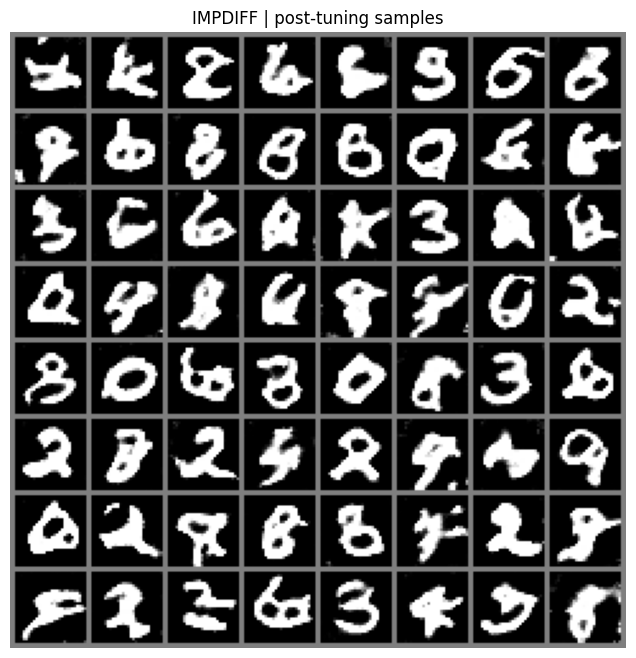

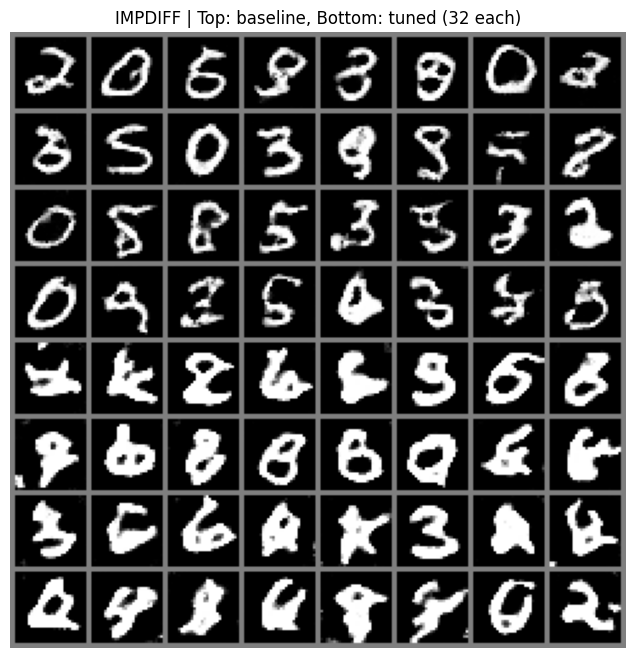

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`


impdiff reward: -0.6854961514472961 -> -0.48681336641311646

=== Fine-tuning mode: SOSMC-ULA ===
[SOSMC-ULA] step     0/1000 | loss= 0.0009 | rew=-0.5911 | rew(w)=-0.5911 | E= 0.023 | E0= 0.023 | ESS= 9994.8 | gamma= 0.005000
  Fresh-sample reward @ step 0: mean=-0.6413 std=0.0679
  Fresh-sample reward @ step 50: mean=-0.4663 std=0.0388
[SOSMC-ULA] step   100/1000 | loss= 0.0000 | rew=-0.5831 | rew(w)=-0.5828 | E=-0.017 | E0= 0.024 | ESS= 9682.6 | gamma= 0.005000
  Fresh-sample reward @ step 100: mean=-0.5090 std=0.0408
  Fresh-sample reward @ step 150: mean=-0.5381 std=0.0396
[SOSMC-ULA] step   200/1000 | loss= 0.0000 | rew=-0.5785 | rew(w)=-0.5785 | E= 0.001 | E0= 0.025 | ESS= 9953.6 | gamma= 0.005000
  Fresh-sample reward @ step 200: mean=-0.5344 std=0.0336
  Fresh-sample reward @ step 250: mean=-0.5359 std=0.0392
[SOSMC-ULA] step   300/1000 | loss= 0.0000 | rew=-0.5736 | rew(w)=-0.5733 | E= 0.019 | E0= 0.026 | ESS= 9775.4 | gamma= 0.005000
  Fresh-sample reward @ step 300: mean=-0.

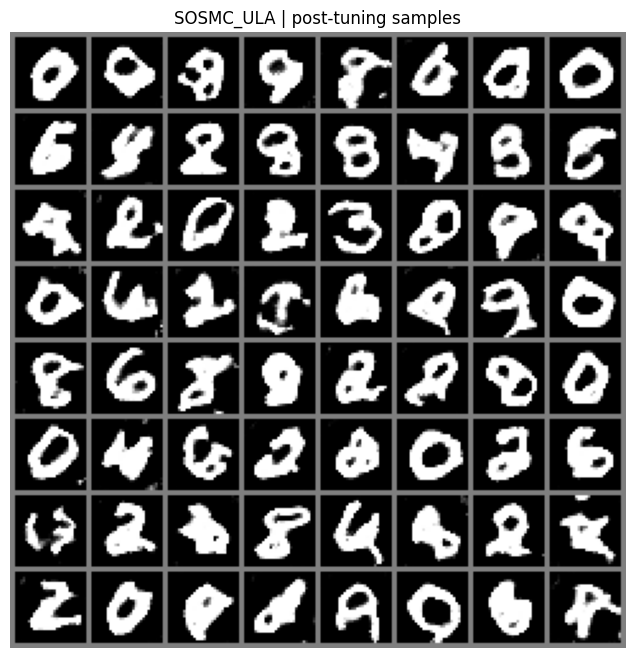

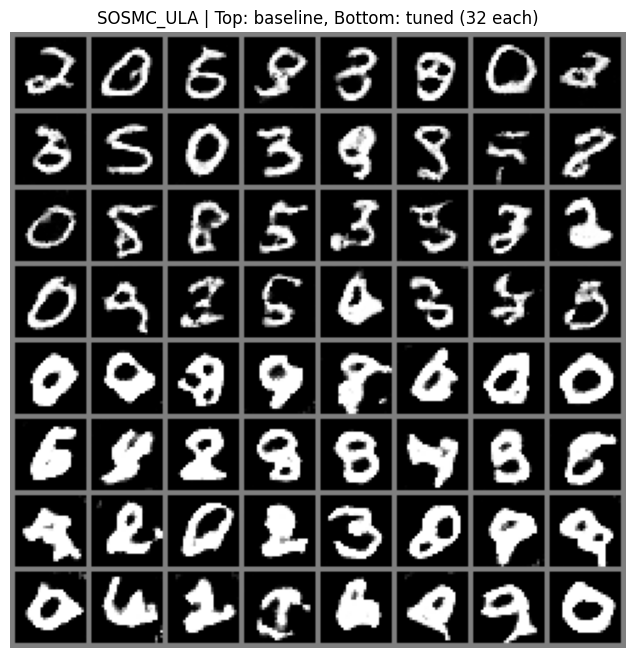

sosmc_ula reward: -0.6854961514472961 -> -0.46113142371177673

ImpDiff reward: -0.6854961514472961 -> -0.48681336641311646
SOSMC-ULA reward: -0.6854961514472961 -> -0.46113142371177673


In [11]:
REWARD_FN = reward_bright

cfg = TrialConfig(
    # Reward tuning
    steps_per_outer=1,
    n_outer=1_000,
    n_particles=10_000,
    lr=1e-4,
    beta_kl=1,
    noise_scale=0.1,

    # Initilisation
    tutorial_steps=256,
    purify_steps=1000,

    # Eval
    eval_n_samples=64,
    eval_steps=256,
    eval_step_size=10.0,
    eval_nrow=8,

    # Fresh Eval
    eval_fresh_frequency = 50,
    eval_fresh_n_samples = 64,
    eval_fresh_n_steps = 128,
    eval_fresh_step_size = 10.0,

    # Logging
    log_every=100,
    show_grids=True,
    seed=42,
    device=device,

    # ImpDiff specific
    gamma_impdiff=5e-3,
    clamp_impdiff=None,
    grad_clip_impdiff=1e8,

    # SOSMC-ULA specific
    gamma_sosmc_ula=5e-3,
    gamma_min=1e-8,
    gamma_max=100,
    adapt_factor=1,
    ess_resample_ratio=0.95,
    ess_adapt_ratio=0.95,
    grad_clip_sosmc_ula=1e8,
)

results_impdiff = _run_mode(
    "impdiff",
    cfg,
    load_model_fn=load_pretrained_dem,
    energy_wrapper_cls=MNISTEnergy,
    impdiff_tuner_cls=ImpDiffTuner,
    sosmc_ula_tuner_cls=SOSMCULATuner,
    sampler_fn=sample_with_original_tutorial_sampler,
    reward_fn=REWARD_FN,
    show_grid_fn=show_grid,
)

results_sosmc_ula = _run_mode(
    "sosmc_ula",
    cfg,
    load_model_fn=load_pretrained_dem,
    energy_wrapper_cls=MNISTEnergy,
    impdiff_tuner_cls=ImpDiffTuner,
    sosmc_ula_tuner_cls=SOSMCULATuner,
    sampler_fn=sample_with_original_tutorial_sampler,
    reward_fn=REWARD_FN,
    show_grid_fn=show_grid,
)

print("\nImpDiff reward:", results_impdiff["baseline_reward_mean"], "->", results_impdiff["post_reward_mean"])
print("SOSMC-ULA reward:", results_sosmc_ula["baseline_reward_mean"], "->", results_sosmc_ula["post_reward_mean"])

runs_both = {"ImpDiff": results_impdiff, "SOSMC-ULA": results_sosmc_ula}


INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`


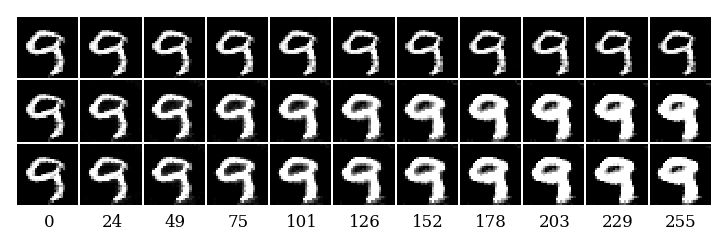

In [ ]:
pretrained = load_pretrained_dem().to(device)
energy_ref = MNISTEnergy(pretrained.cnn).to(device).eval()
for p in energy_ref.parameters():
    p.requires_grad_(False)

x_init = make_training_init_particles(
    energy_ref=energy_ref,
    n_particles=1,          # Num particles to visualise per method
    device=device,
    init_seed=4,
    tutorial_steps=256,
    tutorial_step_size=10.0,
    purify_steps=0,
    gamma=cfg.gamma_sosmc_ula,
    noise_scale=cfg.noise_scale,
    clamp_value=None,
)

impdiff_tuned = load_pretrained_dem().to(device)
impdiff_tuned.cnn.load_state_dict(results_impdiff["tuned_cnn_state_dict"])

sosmc_ula_tuned = load_pretrained_dem().to(device)
sosmc_ula_tuned.cnn.load_state_dict(results_sosmc_ula["tuned_cnn_state_dict"])

visualise_stacked_trajectories(
    {"Pre-trained": pretrained, "ImpDiff": impdiff_tuned, "SOSMC−ULA": sosmc_ula_tuned},
    x_init=x_init[:1],
    steps=256,
    vis_steps=10,
    step_size=10.0,
    label_mode="step_index",
    figsize=(6, 4),
    padding=1,
    pad_value=1,
    row_label_pad=2,
)

## Experiment - $R_{\mathrm{lower-plane}}$

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`



=== Fine-tuning mode: ImpDiff ===
[ImpDiff] step     0/1000 | loss=-0.0002 | rew= 0.0295 | E= 0.062 | E0= 0.062 | 
  Fresh-sample reward @ step 0: mean=0.1477 std=0.0656
  Fresh-sample reward @ step 50: mean=0.5305 std=0.0320
[ImpDiff] step   100/1000 | loss= 0.0000 | rew= 0.0297 | E= 0.091 | E0= 0.063 | 
  Fresh-sample reward @ step 100: mean=0.5458 std=0.0438
  Fresh-sample reward @ step 150: mean=0.5551 std=0.0505
[ImpDiff] step   200/1000 | loss=-0.0000 | rew= 0.0299 | E= 0.084 | E0= 0.064 | 
  Fresh-sample reward @ step 200: mean=0.5396 std=0.0870
  Fresh-sample reward @ step 250: mean=0.5219 std=0.0986
[ImpDiff] step   300/1000 | loss=-0.0000 | rew= 0.0300 | E= 0.068 | E0= 0.066 | 
  Fresh-sample reward @ step 300: mean=0.5150 std=0.1076
  Fresh-sample reward @ step 350: mean=0.4894 std=0.0966
[ImpDiff] step   400/1000 | loss=-0.0001 | rew= 0.0301 | E= 0.048 | E0= 0.066 | 
  Fresh-sample reward @ step 400: mean=0.4693 std=0.0918
  Fresh-sample reward @ step 450: mean=0.4417 std=

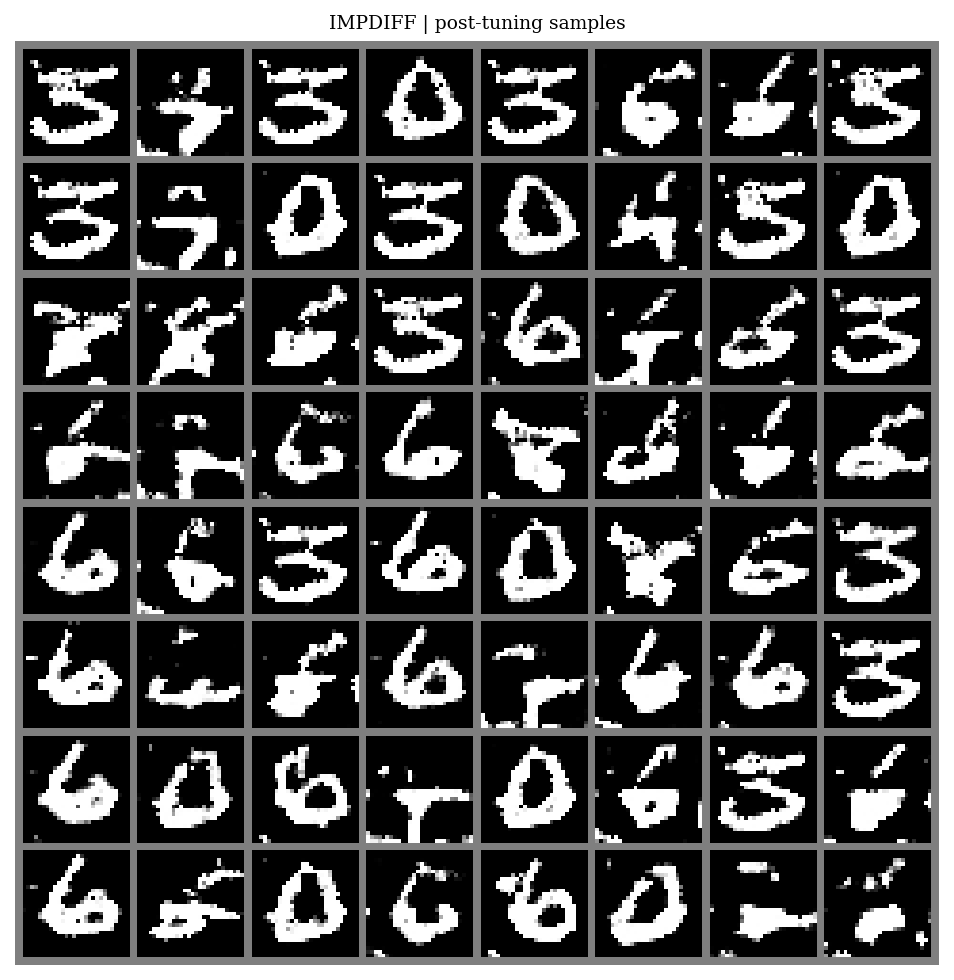

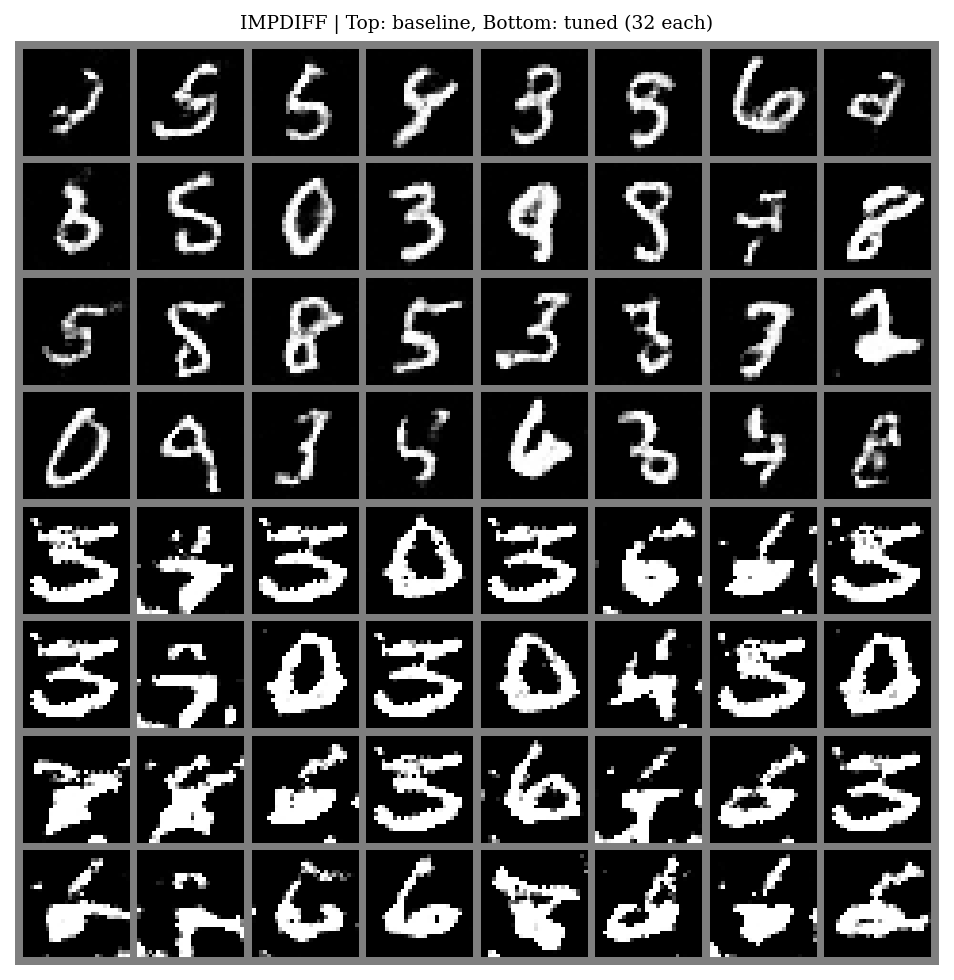

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`


impdiff reward: 0.04058453440666199 -> 0.32867324352264404

=== Fine-tuning mode: SOSMC-ULA ===
[SOSMC-ULA] step     0/1000 | loss=-0.0002 | rew= 0.0295 | rew(w)= 0.0295 | E= 0.062 | E0= 0.062 | ESS= 1998.2 | gamma= 0.003000
  Fresh-sample reward @ step 0: mean=0.1477 std=0.0656
  Fresh-sample reward @ step 50: mean=0.5274 std=0.0329
[SOSMC-ULA] step   100/1000 | loss= 0.0000 | rew= 0.0297 | rew(w)= 0.0324 | E= 0.090 | E0= 0.063 | ESS= 1960.4 | gamma= 0.003000
  Fresh-sample reward @ step 100: mean=0.5461 std=0.0445
  Fresh-sample reward @ step 150: mean=0.5529 std=0.0465
[SOSMC-ULA] step   200/1000 | loss= 0.0000 | rew= 0.0299 | rew(w)= 0.0322 | E= 0.081 | E0= 0.064 | ESS= 1916.6 | gamma= 0.003000
  Fresh-sample reward @ step 200: mean=0.5419 std=0.0832
  Fresh-sample reward @ step 250: mean=0.5294 std=0.0920
[SOSMC-ULA] step   300/1000 | loss= 0.0003 | rew= 0.0321 | rew(w)= 0.0319 | E= 0.073 | E0= 0.076 | ESS= 1956.3 | gamma= 0.003000
  Fresh-sample reward @ step 300: mean=0.5181 std

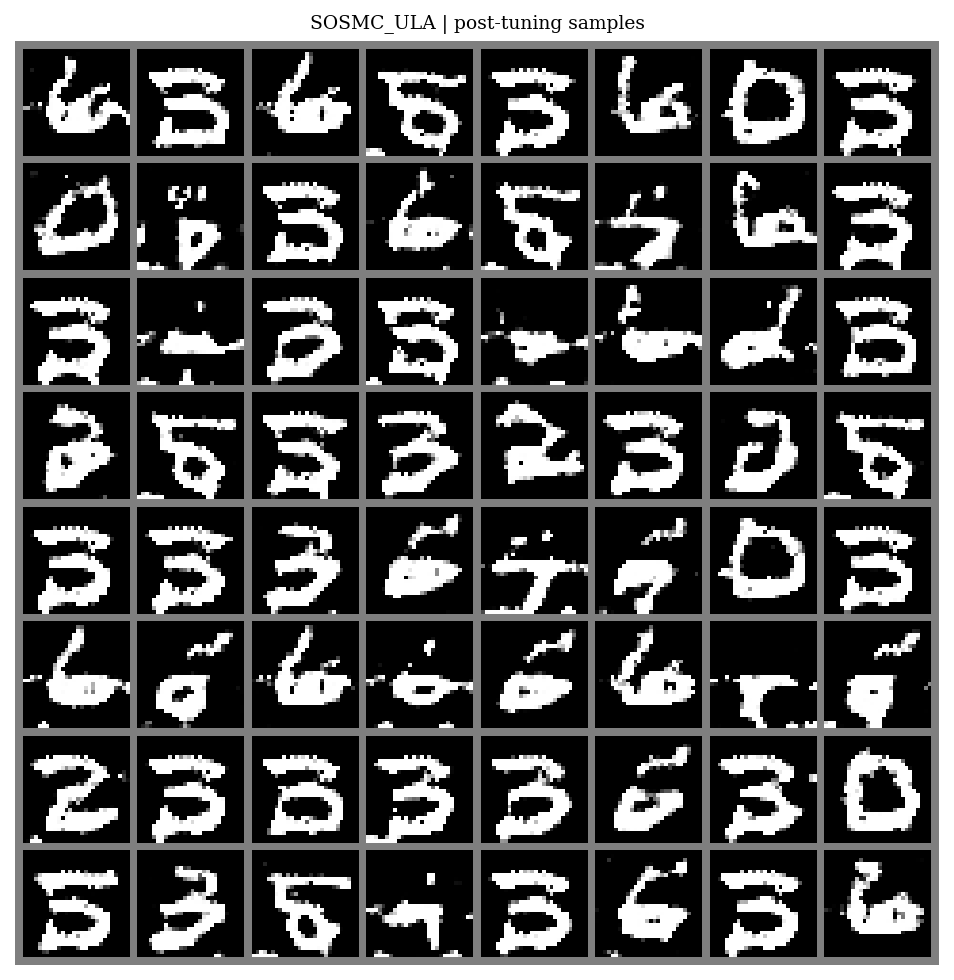

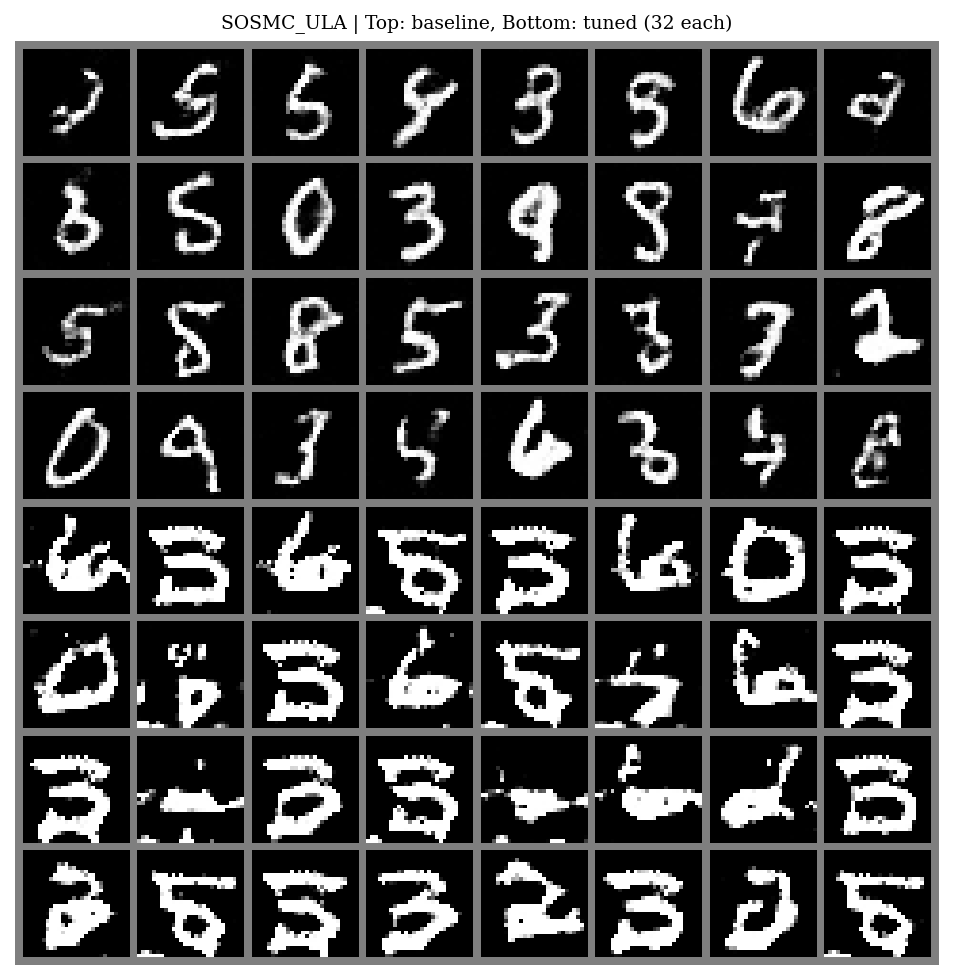

sosmc_ula reward: 0.04058453440666199 -> 0.3376060724258423

ImpDiff reward: 0.04058453440666199 -> 0.32867324352264404
SOSMC-ULA reward: 0.04058453440666199 -> 0.3376060724258423


In [13]:
REWARD_FN = reward_bottom_concentration

cfg = TrialConfig(
    # Reward tuning
    steps_per_outer=1,
    n_outer=1_000,
    n_particles=2_000,
    lr=2e-4,
    beta_kl=1,
    noise_scale=0.4,

    # Initilisation
    tutorial_steps=256,
    purify_steps=2_000,

    # Eval
    eval_n_samples=64,
    eval_steps=1000,
    eval_step_size=10.0,
    eval_nrow=8,

    # Fresh Eval
    eval_fresh_frequency = 50,
    eval_fresh_n_samples = 128,
    eval_fresh_n_steps = 1000,
    eval_fresh_step_size = 10.0,

    # Logging
    log_every=100,
    show_grids=True,
    seed=42,
    device=device,

    # ImpDiff specific
    gamma_impdiff=3e-3,
    clamp_impdiff=None,
    grad_clip_impdiff=1e8,

    # SOSMC-ULA specific
    gamma_sosmc_ula=3e-3,
    gamma_min=1e-8,
    gamma_max=100,
    adapt_factor=1,
    ess_resample_ratio=0.95,
    ess_adapt_ratio=0.975,
    grad_clip_sosmc_ula=1e8,
)

results_impdiff = _run_mode(
    "impdiff",
    cfg,
    load_model_fn=load_pretrained_dem,
    energy_wrapper_cls=MNISTEnergy,
    impdiff_tuner_cls=ImpDiffTuner,
    sosmc_ula_tuner_cls=SOSMCULATuner,
    sampler_fn=sample_with_original_tutorial_sampler,
    reward_fn=REWARD_FN,
    show_grid_fn=show_grid,
)

results_sosmc_ula = _run_mode(
    "sosmc_ula",
    cfg,
    load_model_fn=load_pretrained_dem,
    energy_wrapper_cls=MNISTEnergy,
    impdiff_tuner_cls=ImpDiffTuner,
    sosmc_ula_tuner_cls=SOSMCULATuner,
    sampler_fn=sample_with_original_tutorial_sampler,
    reward_fn=REWARD_FN,
    show_grid_fn=show_grid,
)

print("\nImpDiff reward:", results_impdiff["baseline_reward_mean"], "->", results_impdiff["post_reward_mean"])
print("SOSMC-ULA reward:", results_sosmc_ula["baseline_reward_mean"], "->", results_sosmc_ula["post_reward_mean"])

runs_both = {"ImpDiff": results_impdiff, "SOSMC-ULA": results_sosmc_ula}

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`


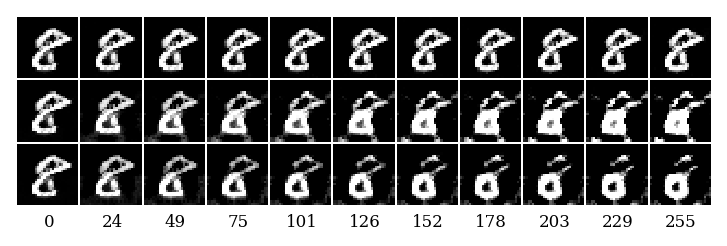

In [ ]:
pretrained = load_pretrained_dem().to(device)
energy_ref = MNISTEnergy(pretrained.cnn).to(device).eval()
for p in energy_ref.parameters():
    p.requires_grad_(False)

x_init = make_training_init_particles(
    energy_ref=energy_ref,
    n_particles=1,
    device=device,
    init_seed=999,
    tutorial_steps=256,
    tutorial_step_size=10.0,
    purify_steps=0,
    gamma=cfg.gamma_sosmc_ula,
    noise_scale=cfg.noise_scale,
    clamp_value=None,
)

impdiff_tuned = load_pretrained_dem().to(device)
impdiff_tuned.cnn.load_state_dict(results_impdiff["tuned_cnn_state_dict"])

sosmc_ula_tuned = load_pretrained_dem().to(device)
sosmc_ula_tuned.cnn.load_state_dict(results_sosmc_ula["tuned_cnn_state_dict"])

visualise_stacked_trajectories(
    {"Pre-trained": pretrained, "ImpDiff": impdiff_tuned, "SOSMC−ULA": sosmc_ula_tuned},
    x_init=x_init[:1],
    steps=256,
    vis_steps=10,
    step_size=10.0,
    label_mode="step_index",
    figsize=(6, 4),
    padding=1,
    pad_value=1,
    row_label_pad=2,
)

## Experiment - $R_{\mathrm{bright}}$ ($\beta_{\mathrm{KL}}$ Sweep)

In [15]:
REWARD_FN = reward_bright

cfg = TrialConfig(
    # Reward tuning
    steps_per_outer=1,
    n_outer=1_000,
    n_particles=1_000,
    lr=1e-4,
    beta_kl=1,  # Overwritten in function call below!
    noise_scale=1,

    # Initilisation
    tutorial_steps=1000,
    purify_steps=0,

    # Eval
    eval_n_samples=64,
    eval_steps=512,
    eval_step_size=10.0,
    eval_nrow=8,

    # Fresh Eval
    eval_fresh_frequency = 50,
    eval_fresh_n_samples = 64,
    eval_fresh_n_steps = 512,
    eval_fresh_step_size = 10.0,

    # Logging
    log_every=100,
    show_grids=True,
    seed=42,
    device=device,

    # ImpDiff specific
    gamma_impdiff=3e-3,
    clamp_impdiff=None,
    grad_clip_impdiff=1e8,

    # SOSMC-ULA specific
    gamma_sosmc_ula=3e-3,
    gamma_min=1e-8,
    gamma_max=1e-2,
    adapt_factor=1.0,
    ess_resample_ratio=0.9,
    ess_adapt_ratio=0.95,
    grad_clip_sosmc_ula=1e8,
)

betas = [5.0, 2.0, 1.0, 0.5]
results_sosmc_ula_by_beta = run_beta_sweep_for_method(
    betas,
    base_cfg=cfg,
    mode="sosmc_ula",
    load_model_fn=load_pretrained_dem,
    energy_wrapper_cls=MNISTEnergy,
    impdiff_tuner_cls=ImpDiffTuner,
    sosmc_ula_tuner_cls=SOSMCULATuner,
    sampler_fn=sample_with_original_tutorial_sampler,
    reward_fn=REWARD_FN,
    show_grid_fn=None,
)

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`




===== SOSMC_ULA sweep: beta_kl = 5.0 =====

=== Fine-tuning mode: SOSMC-ULA ===
[SOSMC-ULA] step     0/1000 | loss= 0.0003 | rew=-0.7507 | rew(w)=-0.7507 | E=-0.012 | E0=-0.012 | ESS= 1000.0 | gamma= 0.003000
  Fresh-sample reward @ step 0: mean=-0.6535 std=0.0581
  Fresh-sample reward @ step 50: mean=-0.5849 std=0.0466
[SOSMC-ULA] step   100/1000 | loss=-0.0000 | rew=-0.5197 | rew(w)=-0.5192 | E= 0.010 | E0=-0.002 | ESS= 999.9 | gamma= 0.003000
  Fresh-sample reward @ step 100: mean=-0.6144 std=0.0440
  Fresh-sample reward @ step 150: mean=-0.6318 std=0.0544
[SOSMC-ULA] step   200/1000 | loss= 0.0004 | rew=-0.4343 | rew(w)=-0.4341 | E= 0.021 | E0= 0.009 | ESS= 999.9 | gamma= 0.003000
  Fresh-sample reward @ step 200: mean=-0.6395 std=0.0531
  Fresh-sample reward @ step 250: mean=-0.6407 std=0.0555
[SOSMC-ULA] step   300/1000 | loss=-0.0001 | rew=-0.3801 | rew(w)=-0.3799 | E= 0.031 | E0= 0.020 | ESS= 999.9 | gamma= 0.003000
  Fresh-sample reward @ step 300: mean=-0.6350 std=0.0531
  

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`


sosmc_ula reward: -0.7226470708847046 -> -0.6500093936920166


===== SOSMC_ULA sweep: beta_kl = 2.0 =====

=== Fine-tuning mode: SOSMC-ULA ===
[SOSMC-ULA] step     0/1000 | loss= 0.0003 | rew=-0.7507 | rew(w)=-0.7507 | E=-0.012 | E0=-0.012 | ESS= 1000.0 | gamma= 0.003000
  Fresh-sample reward @ step 0: mean=-0.6535 std=0.0581
  Fresh-sample reward @ step 50: mean=-0.4076 std=0.0385
[SOSMC-ULA] step   100/1000 | loss= 0.0000 | rew=-0.5196 | rew(w)=-0.5186 | E= 0.014 | E0=-0.002 | ESS= 999.4 | gamma= 0.003000
  Fresh-sample reward @ step 100: mean=-0.5229 std=0.0363
  Fresh-sample reward @ step 150: mean=-0.5644 std=0.0392
[SOSMC-ULA] step   200/1000 | loss= 0.0001 | rew=-0.4342 | rew(w)=-0.4335 | E= 0.023 | E0= 0.009 | ESS= 999.5 | gamma= 0.003000
  Fresh-sample reward @ step 200: mean=-0.5830 std=0.0427
  Fresh-sample reward @ step 250: mean=-0.5898 std=0.0433
[SOSMC-ULA] step   300/1000 | loss= 0.0001 | rew=-0.3800 | rew(w)=-0.3796 | E= 0.039 | E0= 0.020 | ESS= 999.6 | gamma= 0.003000

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`


sosmc_ula reward: -0.7226470708847046 -> -0.5594520568847656


===== SOSMC_ULA sweep: beta_kl = 1.0 =====

=== Fine-tuning mode: SOSMC-ULA ===
[SOSMC-ULA] step     0/1000 | loss= 0.0003 | rew=-0.7507 | rew(w)=-0.7507 | E=-0.012 | E0=-0.012 | ESS= 1000.0 | gamma= 0.003000
  Fresh-sample reward @ step 0: mean=-0.6535 std=0.0581
  Fresh-sample reward @ step 50: mean=-0.3099 std=0.0269
[SOSMC-ULA] step   100/1000 | loss= 0.0000 | rew=-0.5196 | rew(w)=-0.5175 | E= 0.020 | E0=-0.002 | ESS= 997.7 | gamma= 0.003000
  Fresh-sample reward @ step 100: mean=-0.3848 std=0.0252
  Fresh-sample reward @ step 150: mean=-0.4716 std=0.0312
[SOSMC-ULA] step   200/1000 | loss= 0.0000 | rew=-0.4342 | rew(w)=-0.4327 | E= 0.026 | E0= 0.010 | ESS= 998.1 | gamma= 0.003000
  Fresh-sample reward @ step 200: mean=-0.4989 std=0.0349
  Fresh-sample reward @ step 250: mean=-0.5124 std=0.0351
[SOSMC-ULA] step   300/1000 | loss=-0.0000 | rew=-0.3799 | rew(w)=-0.3788 | E= 0.043 | E0= 0.020 | ESS= 998.3 | gamma= 0.003000

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`


sosmc_ula reward: -0.7226470708847046 -> -0.46727293729782104


===== SOSMC_ULA sweep: beta_kl = 0.5 =====

=== Fine-tuning mode: SOSMC-ULA ===
[SOSMC-ULA] step     0/1000 | loss= 0.0003 | rew=-0.7507 | rew(w)=-0.7507 | E=-0.012 | E0=-0.012 | ESS= 1000.0 | gamma= 0.003000
  Fresh-sample reward @ step 0: mean=-0.6535 std=0.0581
  Fresh-sample reward @ step 50: mean=-0.2693 std=0.0300
[SOSMC-ULA] step   100/1000 | loss= 0.0000 | rew=-0.5196 | rew(w)=-0.5152 | E= 0.034 | E0=-0.002 | ESS= 990.5 | gamma= 0.003000
  Fresh-sample reward @ step 100: mean=-0.2716 std=0.0217
  Fresh-sample reward @ step 150: mean=-0.3266 std=0.0254
[SOSMC-ULA] step   200/1000 | loss= 0.0000 | rew=-0.4341 | rew(w)=-0.4309 | E= 0.045 | E0= 0.010 | ESS= 992.3 | gamma= 0.003000
  Fresh-sample reward @ step 200: mean=-0.4027 std=0.0301
  Fresh-sample reward @ step 250: mean=-0.4186 std=0.0296
[SOSMC-ULA] step   300/1000 | loss=-0.0000 | rew=-0.3798 | rew(w)=-0.3773 | E= 0.051 | E0= 0.021 | ESS= 993.2 | gamma= 0.00300

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanent

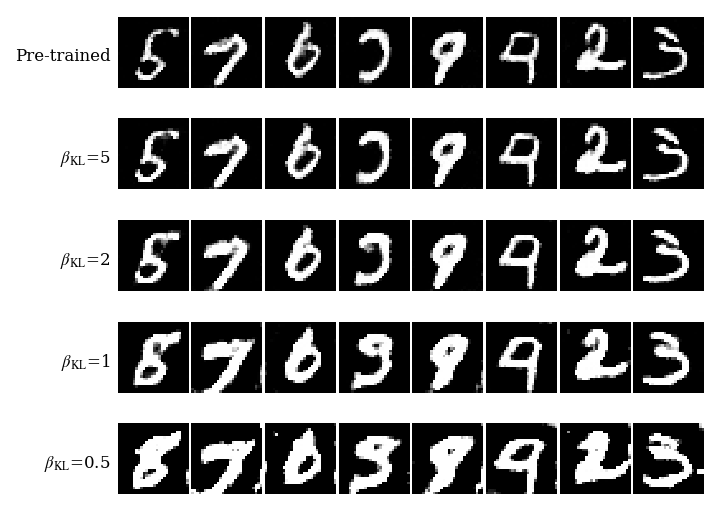

In [ ]:
# Pretrained model
pretrained = load_pretrained_dem().to(device)

# Shared reference for init
energy_ref = MNISTEnergy(pretrained.cnn).to(device).eval()
for p in energy_ref.parameters():
    p.requires_grad_(False)

# Shared init for all rows
x_init = make_training_init_particles(
    energy_ref=energy_ref,
    n_particles=64,
    device=device,
    init_seed=1,
    tutorial_steps=512,
    tutorial_step_size=10.0,
    purify_steps=0,
    gamma=cfg.gamma_sosmc_ula,
    noise_scale=cfg.noise_scale,
    clamp_value=None,
)

# Build the rows (pretrained + all betas (sorted high -> low))
model_rows, betas_sorted = build_models_for_beta_rows(
    pretrained,
    results_sosmc_ula_by_beta,
    device=device,
    label_prefix=r"$\beta_{\mathrm{KL}}$=",
    descending=True,
)

finals = final_samples_by_model(
    model_rows,
    x_init=x_init[:8],
    reward_fn=REWARD_FN,
    steps=512,
    step_size=10.0,
    sampler_noise_seed=999,
    padding=1,
    pad_value=1.0,
    row_gap_px=10,
    figsize=(6.8, 0.55 + 0.55*len(model_rows)),
)

## Experiment - $R_{\mathrm{dark}}$ ($\beta_{\mathrm{KL}}$ Sweep)

In [17]:
def reward_dark(x: torch.Tensor) -> torch.Tensor:
    x = x.clamp(-1.0, 1.0)
    return -x.mean(dim=(1, 2, 3)) / 2

REWARD_FN = reward_dark

cfg = TrialConfig(
    # Reward tuning
    steps_per_outer=1,
    n_outer=1_000,
    n_particles=1_000,
    lr=1e-4,
    beta_kl=1, # Overwritten in function call below!
    noise_scale=1,

    # Initilisation
    tutorial_steps=1000,
    purify_steps=0,

    # Eval
    eval_n_samples=64,
    eval_steps=512,
    eval_step_size=10.0,
    eval_nrow=8,

    # Fresh Eval
    eval_fresh_frequency = 50,
    eval_fresh_n_samples = 64,
    eval_fresh_n_steps = 512,
    eval_fresh_step_size = 10.0,

    # Logging
    log_every=100,
    show_grids=True,
    seed=42,
    device=device,

    # ImpDiff specific
    gamma_impdiff=3e-3,
    clamp_impdiff=None,
    grad_clip_impdiff=1e8,

    # SOSMC-ULA specific
    gamma_sosmc_ula=3e-3,
    gamma_min=1e-8,
    gamma_max=1e-2,
    adapt_factor=1.0,
    ess_resample_ratio=0.9,
    ess_adapt_ratio=0.95,
    grad_clip_sosmc_ula=1e8,
)

betas = [5.0, 2.0, 1.0, 0.5]
results_sosmc_ula_by_beta = run_beta_sweep_for_method(
    betas,
    base_cfg=cfg,
    mode="sosmc_ula",
    load_model_fn=load_pretrained_dem,
    energy_wrapper_cls=MNISTEnergy,
    impdiff_tuner_cls=ImpDiffTuner,
    sosmc_ula_tuner_cls=SOSMCULATuner,
    sampler_fn=sample_with_original_tutorial_sampler,
    reward_fn=REWARD_FN,
    show_grid_fn=None,
)

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`




===== SOSMC_ULA sweep: beta_kl = 5.0 =====

=== Fine-tuning mode: SOSMC-ULA ===
[SOSMC-ULA] step     0/1000 | loss=-0.0002 | rew= 0.3753 | rew(w)= 0.3753 | E=-0.012 | E0=-0.012 | ESS= 1000.0 | gamma= 0.003000
  Fresh-sample reward @ step 0: mean=0.3826 std=0.0366
  Fresh-sample reward @ step 50: mean=0.4196 std=0.0273
[SOSMC-ULA] step   100/1000 | loss=-0.0001 | rew= 0.2598 | rew(w)= 0.2599 | E=-0.012 | E0=-0.002 | ESS= 1000.0 | gamma= 0.003000
  Fresh-sample reward @ step 100: mean=0.4144 std=0.0270
  Fresh-sample reward @ step 150: mean=0.4040 std=0.0260
[SOSMC-ULA] step   200/1000 | loss= 0.0001 | rew= 0.2172 | rew(w)= 0.2172 | E= 0.001 | E0= 0.009 | ESS= 1000.0 | gamma= 0.003000
  Fresh-sample reward @ step 200: mean=0.3950 std=0.0334
  Fresh-sample reward @ step 250: mean=0.3922 std=0.0344
[SOSMC-ULA] step   300/1000 | loss=-0.0000 | rew= 0.1901 | rew(w)= 0.1901 | E= 0.008 | E0= 0.020 | ESS= 1000.0 | gamma= 0.003000
  Fresh-sample reward @ step 300: mean=0.3916 std=0.0322
  Fres

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`


sosmc_ula reward: 0.3613235354423523 -> 0.3907555341720581


===== SOSMC_ULA sweep: beta_kl = 2.0 =====

=== Fine-tuning mode: SOSMC-ULA ===
[SOSMC-ULA] step     0/1000 | loss=-0.0002 | rew= 0.3753 | rew(w)= 0.3753 | E=-0.012 | E0=-0.012 | ESS= 1000.0 | gamma= 0.003000
  Fresh-sample reward @ step 0: mean=0.3826 std=0.0366
  Fresh-sample reward @ step 50: mean=0.4880 std=0.0058
[SOSMC-ULA] step   100/1000 | loss= 0.0000 | rew= 0.2598 | rew(w)= 0.2601 | E=-0.019 | E0=-0.002 | ESS= 999.8 | gamma= 0.003000
  Fresh-sample reward @ step 100: mean=0.4789 std=0.0121
  Fresh-sample reward @ step 150: mean=0.4731 std=0.0109
[SOSMC-ULA] step   200/1000 | loss= 0.0002 | rew= 0.2172 | rew(w)= 0.2174 | E=-0.002 | E0= 0.009 | ESS= 999.9 | gamma= 0.003000
  Fresh-sample reward @ step 200: mean=0.4633 std=0.0204
  Fresh-sample reward @ step 250: mean=0.4541 std=0.0195
[SOSMC-ULA] step   300/1000 | loss= 0.0001 | rew= 0.1901 | rew(w)= 0.1902 | E= 0.002 | E0= 0.020 | ESS= 999.9 | gamma= 0.003000
  Fresh

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`


sosmc_ula reward: 0.3613235354423523 -> 0.43306055665016174


===== SOSMC_ULA sweep: beta_kl = 1.0 =====

=== Fine-tuning mode: SOSMC-ULA ===
[SOSMC-ULA] step     0/1000 | loss=-0.0002 | rew= 0.3753 | rew(w)= 0.3753 | E=-0.012 | E0=-0.012 | ESS= 1000.0 | gamma= 0.003000
  Fresh-sample reward @ step 0: mean=0.3826 std=0.0366
  Fresh-sample reward @ step 50: mean=0.4953 std=0.0011
[SOSMC-ULA] step   100/1000 | loss=-0.0000 | rew= 0.2599 | rew(w)= 0.2604 | E=-0.033 | E0=-0.002 | ESS= 999.4 | gamma= 0.003000
  Fresh-sample reward @ step 100: mean=0.4960 std=0.0012
  Fresh-sample reward @ step 150: mean=0.4942 std=0.0017
[SOSMC-ULA] step   200/1000 | loss= 0.0000 | rew= 0.2172 | rew(w)= 0.2176 | E=-0.008 | E0= 0.009 | ESS= 999.6 | gamma= 0.003000
  Fresh-sample reward @ step 200: mean=0.4935 std=0.0021
  Fresh-sample reward @ step 250: mean=0.4916 std=0.0027
[SOSMC-ULA] step   300/1000 | loss= 0.0000 | rew= 0.1901 | rew(w)= 0.1904 | E= 0.000 | E0= 0.020 | ESS= 999.6 | gamma= 0.003000
  Fres

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`


sosmc_ula reward: 0.3613235354423523 -> 0.47891807556152344


===== SOSMC_ULA sweep: beta_kl = 0.5 =====

=== Fine-tuning mode: SOSMC-ULA ===
[SOSMC-ULA] step     0/1000 | loss=-0.0002 | rew= 0.3753 | rew(w)= 0.3753 | E=-0.012 | E0=-0.012 | ESS= 1000.0 | gamma= 0.003000
  Fresh-sample reward @ step 0: mean=0.3826 std=0.0366
  Fresh-sample reward @ step 50: mean=0.4818 std=0.0009
[SOSMC-ULA] step   100/1000 | loss= 0.0000 | rew= 0.2599 | rew(w)= 0.2609 | E=-0.062 | E0=-0.002 | ESS= 997.9 | gamma= 0.003000
  Fresh-sample reward @ step 100: mean=0.4984 std=0.0004
  Fresh-sample reward @ step 150: mean=0.4980 std=0.0006
[SOSMC-ULA] step   200/1000 | loss=-0.0000 | rew= 0.2173 | rew(w)= 0.2179 | E=-0.018 | E0= 0.009 | ESS= 998.5 | gamma= 0.003000
  Fresh-sample reward @ step 200: mean=0.4978 std=0.0006
  Fresh-sample reward @ step 250: mean=0.4967 std=0.0008
[SOSMC-ULA] step   300/1000 | loss=-0.0000 | rew= 0.1902 | rew(w)= 0.1906 | E=-0.003 | E0= 0.019 | ESS= 998.8 | gamma= 0.003000
  Fres

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/tutorial8/MNIST.ckpt`
INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.0. To apply the upgrade to your files permanent

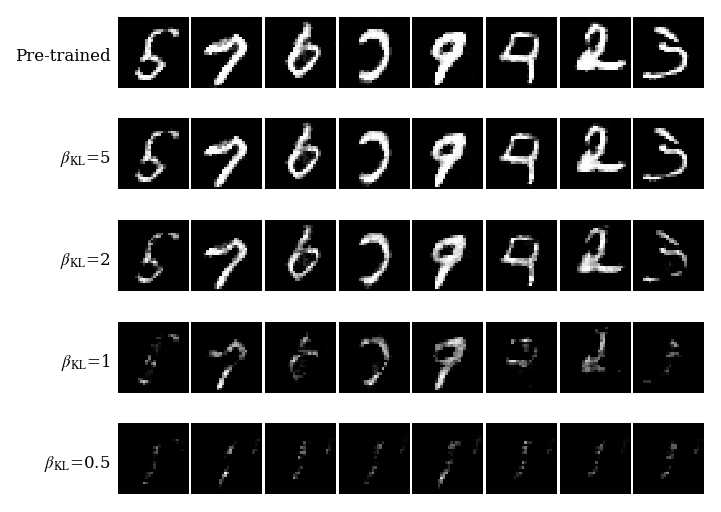

In [ ]:
# Pretrained model
pretrained = load_pretrained_dem().to(device)

# Shared reference for init
energy_ref = MNISTEnergy(pretrained.cnn).to(device).eval()
for p in energy_ref.parameters():
    p.requires_grad_(False)

# Shared init for all rows
x_init = make_training_init_particles(
    energy_ref=energy_ref,
    n_particles=64,
    device=device,
    init_seed=1,
    tutorial_steps=512,
    tutorial_step_size=10.0,
    purify_steps=0,
    gamma=cfg.gamma_sosmc_ula,
    noise_scale=cfg.noise_scale,
    clamp_value=None,
)

# Build the rows (pretrained + all betas (sorted high -> low))
model_rows, betas_sorted = build_models_for_beta_rows(
    pretrained,
    results_sosmc_ula_by_beta,
    device=device,
    label_prefix=r"$\beta_{\mathrm{KL}}$=",
    descending=True,
)

finals = final_samples_by_model(
    model_rows,
    x_init=x_init[:8],
    reward_fn=REWARD_FN,
    steps=512,
    step_size=10.0,
    sampler_noise_seed=9,
    padding=1,
    pad_value=1.0,
    row_gap_px=10,
    figsize=(6.8, 0.55 + 0.55*len(model_rows)),
)